# Task 1.1 — Verify TensorFlow Installation

In [2]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import tensorflow as tf
import numpy as np

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

# Tensors are the core data structure - like NumPy arrays but GPU-ready
scalar = tf.constant(5)                 # rank 0 -> a single number
vector = tf.constant([1, 2, 3])         # rank 1 -> a 1D list of numbers
matrix = tf.constant([[1, 2], [3, 4]])  # rank 2 -> a 2D grid of numbers

# Rank = number of dimensions, Shape = size along each dimension
print(f'Scalar shape: {scalar.shape}, rank: {tf.rank(scalar).numpy()}')
print(f'Vector shape: {vector.shape}, rank: {tf.rank(vector).numpy()}')
print(f'Matrix shape: {matrix.shape}, rank: {tf.rank(matrix).numpy()}')

# Tensors support math ops like NumPy arrays
print(matrix + 10)
print(tf.matmul(matrix, matrix))

TensorFlow version: 2.21.0
GPU available: False
Scalar shape: (), rank: 0
Vector shape: (3,), rank: 1
Matrix shape: (2, 2), rank: 2
tf.Tensor(
[[11 12]
 [13 14]], shape=(2, 2), dtype=int32)
tf.Tensor(
[[ 7 10]
 [15 22]], shape=(2, 2), dtype=int32)


# Task 1.2 — Understand the Building Blocks

In [4]:
pip install matplotlib pandas scikit-learn seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


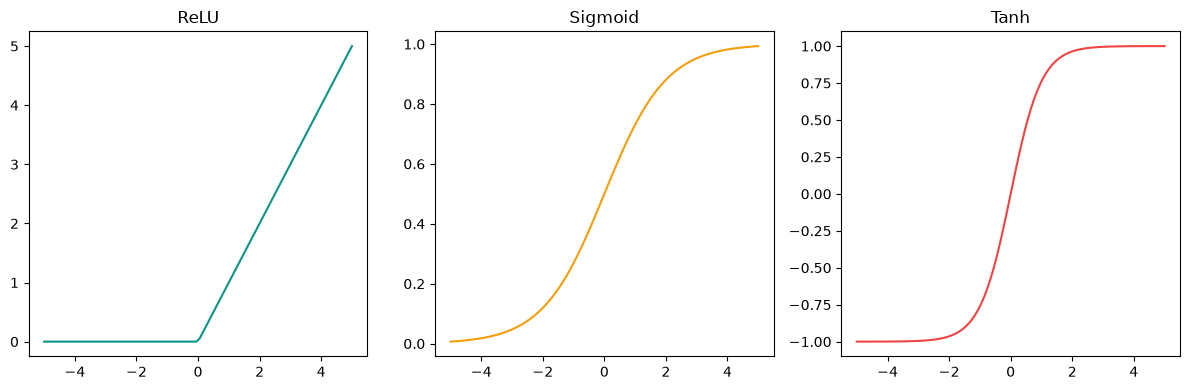

In [5]:
# DENSE LAYER: every neuron connects to every neuron in the previous layer
#   Dense(64) = 64 neurons in this layer
#
# ACTIVATION FUNCTIONS: add non-linearity so the network can learn complex patterns
#   relu    -> hidden layers (most common)
#   sigmoid -> BINARY classification output (0 to 1)
#   softmax -> MULTI-CLASS output (probabilities summing to 1)
#   linear  -> REGRESSION output (no activation)
#
# LOSS FUNCTIONS:
#   binary_crossentropy      -> binary classification
#   categorical_crossentropy -> multi-class classification
#   mse / mae                -> regression
#
# OPTIMIZER: adam -> good default for almost everything

from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# Visualize the three main activation curves
x = np.linspace(-5, 5, 100)
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.plot(x, np.maximum(0, x), color='#0D9488'); plt.title('ReLU')
plt.subplot(1, 3, 2); plt.plot(x, 1/(1+np.exp(-x)), color='#F59E0B'); plt.title('Sigmoid')
plt.subplot(1, 3, 3); plt.plot(x, np.tanh(x), color='#EF4444'); plt.title('Tanh')
plt.tight_layout()
plt.savefig('activation_functions.png', dpi=150)
plt.show()

# Task 1.3 — Build Your First Model

In [1]:
from tensorflow import keras
from tensorflow.keras import layers

# Sequential = a simple stack of layers, one after another
model = keras.Sequential([
    layers.Input(shape=(3,)),               # 3 input features
    layers.Dense(16, activation='relu'),    # hidden layer 1
    layers.Dense(8, activation='relu'),     # hidden layer 2
    layers.Dense(1, activation='sigmoid'),  # binary output
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()
# Dense(16) from 3 inputs = (3 * 16) + 16 bias = 64 parameters
# Dense(8) from 16 inputs = (16 * 8) + 8 bias = 136 parameters
# Dense(1) from 8 inputs  = (8 * 1) + 1 bias  = 9 parameters

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)